In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [4]:
population_df = pd.read_csv("../dataset/cleaned_population_dataset.csv")
params_df = pd.read_csv("../dataset/cleaned_general_parameters_dataset.csv")
mortality_df = pd.read_csv("../dataset/cleaned_mortality_parameters_dataset.csv")

In [5]:
age_groups = ["0", "1-14", "15-64", "65-89", "90+"]
sexes = ["Male", "Female"]

stocks = [(age, sex) for age in age_groups for sex in sexes]
stock_index = {stock: i for i, stock in enumerate(stocks)}

print(stocks)

[('0', 'Male'), ('0', 'Female'), ('1-14', 'Male'), ('1-14', 'Female'), ('15-64', 'Male'), ('15-64', 'Female'), ('65-89', 'Male'), ('65-89', 'Female'), ('90+', 'Male'), ('90+', 'Female')]


In [7]:
future_start_year = 2020
future_end_year = 2030

future_years = np.arange(future_start_year, future_end_year + 1)
recent_years = range(2015, 2020)

recent_params = params_df[params_df["Year"].isin(recent_years)]

avg_total_fertility_rate = recent_params["Total fertility rate"].mean()
avg_net_migration_rate = recent_params["Net Migration Rate"].mean()
avg_p_male = recent_params["p_male"].mean()
avg_p_female = recent_params["p_female"].mean()

future_params_df = pd.DataFrame({
    "Year": future_years,
    "Total fertility rate": avg_total_fertility_rate,
    "Net Migration Rate": avg_net_migration_rate,
    "p_male": avg_p_male,
    "p_female": avg_p_female
})

future_params_df

,Year,Total fertility rate,Net Migration Rate,p_male,p_female
0,2020,1.497501,0.006933,0.5134,0.4866
1,2021,1.497501,0.006933,0.5134,0.4866
2,2022,1.497501,0.006933,0.5134,0.4866
3,2023,1.497501,0.006933,0.5134,0.4866
4,2024,1.497501,0.006933,0.5134,0.4866
5,2025,1.497501,0.006933,0.5134,0.4866
6,2026,1.497501,0.006933,0.5134,0.4866
7,2027,1.497501,0.006933,0.5134,0.4866
8,2028,1.497501,0.006933,0.5134,0.4866
9,2029,1.497501,0.006933,0.5134,0.4866


In [8]:
recent_mortality = mortality_df[mortality_df["Year"].isin(recent_years)]

avg_mortality = (
    recent_mortality
    .groupby(["Age", "Sex"], as_index=False)["Mortality Rate"]
    .mean()
)

future_mortality_rows = []

for year in future_years:
    for _, row in avg_mortality.iterrows():
        future_mortality_rows.append({
            "Year": year,
            "Age": row["Age"],
            "Sex": row["Sex"],
            "Mortality Rate": row["Mortality Rate"]
        })

future_mortality_df = pd.DataFrame(future_mortality_rows)

future_mortality_df.head(20)

,Year,Age,Sex,Mortality Rate
0,2020,0,Female,0.002710
1,2020,0,Male,0.003258
2,2020,1-14,Female,0.000090
3,2020,1-14,Male,0.000118
4,2020,15-64,Female,0.001425
5,2020,15-64,Male,0.002715
6,2020,65-89,Female,0.038668
7,2020,65-89,Male,0.056823
8,2020,90+,Female,0.351942
9,2020,90+,Male,0.379851


In [9]:
params_df_extended = pd.concat(
    [params_df, future_params_df],
    ignore_index=True
)

mortality_df_extended = pd.concat(
    [mortality_df, future_mortality_df],
    ignore_index=True
)

print(params_df_extended.tail(15))
print(mortality_df_extended.tail(20))

    Year  Net Migration Rate  Total fertility rate  p_male  p_female
16  2016            0.007551              1.531366  0.5134    0.4866
17  2017            0.005169              1.520947  0.5134    0.4866
18  2018            0.003992              1.478848  0.5134    0.4866
19  2019            0.004627              1.464192  0.5134    0.4866
20  2020            0.006933              1.497501  0.5134    0.4866
21  2021            0.006933              1.497501  0.5134    0.4866
22  2022            0.006933              1.497501  0.5134    0.4866
23  2023            0.006933              1.497501  0.5134    0.4866
24  2024            0.006933              1.497501  0.5134    0.4866
25  2025            0.006933              1.497501  0.5134    0.4866
26  2026            0.006933              1.497501  0.5134    0.4866
27  2027            0.006933              1.497501  0.5134    0.4866
28  2028            0.006933              1.497501  0.5134    0.4866
29  2029            0.006933      

In [10]:
def get_year(t):
    return int(np.floor(t))

In [11]:
def get_general_params_future(t):
    year = get_year(t)

    year = max(
        params_df_extended["Year"].min(),
        min(year, params_df_extended["Year"].max())
    )

    row = params_df_extended[params_df_extended["Year"] == year].iloc[0]

    return {
        "total_fertility_rate": row["Total fertility rate"],
        "net_migration_rate": row["Net Migration Rate"],
        "p_male": row["p_male"],
        "p_female": row["p_female"]
    }

In [12]:
def get_mortality_rate_future(t, age_group, sex):
    year = get_year(t)

    year = max(
        mortality_df_extended["Year"].min(),
        min(year, mortality_df_extended["Year"].max())
    )

    row = mortality_df_extended[
        (mortality_df_extended["Year"] == year) &
        (mortality_df_extended["Age"] == age_group) &
        (mortality_df_extended["Sex"] == sex)
    ]

    return row["Mortality Rate"].values[0]

In [13]:
def population_ode_future(t, y):
    dydt = np.zeros_like(y)

    params = get_general_params_future(t)

    total_fertility_rate = params["total_fertility_rate"]
    net_migration_rate = params["net_migration_rate"]
    p_male = params["p_male"]
    p_female = params["p_female"]

    yearly_fertility_rate = total_fertility_rate / 35

    female_15_64 = y[stock_index[("15-64", "Female")]]

    total_births = yearly_fertility_rate * female_15_64
    births_male = p_male * total_births
    births_female = p_female * total_births

    for sex in sexes:
        births = births_male if sex == "Male" else births_female

        idx_0 = stock_index[("0", sex)]
        idx_1_14 = stock_index[("1-14", sex)]
        idx_15_64 = stock_index[("15-64", sex)]
        idx_65_89 = stock_index[("65-89", sex)]
        idx_90 = stock_index[("90+", sex)]

        mu_0 = get_mortality_rate_future(t, "0", sex)
        mu_1_14 = get_mortality_rate_future(t, "1-14", sex)
        mu_15_64 = get_mortality_rate_future(t, "15-64", sex)
        mu_65_89 = get_mortality_rate_future(t, "65-89", sex)
        mu_90 = get_mortality_rate_future(t, "90+", sex)

        aging_0_to_1_14 = y[idx_0] / 1
        aging_1_14_to_15_64 = y[idx_1_14] / 14
        aging_15_64_to_65_89 = y[idx_15_64] / 50
        aging_65_89_to_90 = y[idx_65_89] / 25

        dydt[idx_0] += births
        dydt[idx_0] += net_migration_rate * y[idx_0]
        dydt[idx_0] -= mu_0 * y[idx_0]
        dydt[idx_0] -= aging_0_to_1_14

        dydt[idx_1_14] += aging_0_to_1_14
        dydt[idx_1_14] += net_migration_rate * y[idx_1_14]
        dydt[idx_1_14] -= mu_1_14 * y[idx_1_14]
        dydt[idx_1_14] -= aging_1_14_to_15_64

        dydt[idx_15_64] += aging_1_14_to_15_64
        dydt[idx_15_64] += net_migration_rate * y[idx_15_64]
        dydt[idx_15_64] -= mu_15_64 * y[idx_15_64]
        dydt[idx_15_64] -= aging_15_64_to_65_89

        dydt[idx_65_89] += aging_15_64_to_65_89
        dydt[idx_65_89] += net_migration_rate * y[idx_65_89]
        dydt[idx_65_89] -= mu_65_89 * y[idx_65_89]
        dydt[idx_65_89] -= aging_65_89_to_90

        dydt[idx_90] += aging_65_89_to_90
        dydt[idx_90] += net_migration_rate * y[idx_90]
        dydt[idx_90] -= mu_90 * y[idx_90]

    return dydt

In [14]:
prediction_start_year = 2019
prediction_end_year = 2030

start_pop_2019 = population_df[population_df["Year"] == prediction_start_year].copy()

y0_future = []

for age, sex in stocks:
    value = start_pop_2019[
        (start_pop_2019["Age"] == age) &
        (start_pop_2019["Sex"] == sex)
    ]["Population"].values[0]

    y0_future.append(value)

y0_future = np.array(y0_future)

print(y0_future)
print("Initial 2019 total population:", y0_future.sum())

[  88007.    83392.   570621.   538855.  2979886.5 2938050.   707386.5
  891722.5   22587.5   60368. ]
Initial 2019 total population: 8880876.0


In [15]:
t_eval_future = np.arange(prediction_start_year, prediction_end_year + 1)

future_solution = solve_ivp(
    fun=population_ode_future,
    t_span=(prediction_start_year, prediction_end_year),
    y0=y0_future,
    t_eval=t_eval_future,
    method="RK45"
)

print(future_solution.success)
print(future_solution.message)

True
The solver successfully reached the end of the integration interval.


In [16]:
future_prediction_df = pd.DataFrame(
    future_solution.y.T,
    columns=[f"{age}_{sex}" for age, sex in stocks]
)

future_prediction_df["Year"] = future_solution.t.astype(int)

future_prediction_df["predicted_total_population"] = future_prediction_df[
    [f"{age}_{sex}" for age, sex in stocks]
].sum(axis=1)

future_prediction_df

,0_Male,0_Female,1-14_Male,1-14_Female,15-64_Male,15-64_Female,65-89_Male,65-89_Female,90+_Male,90+_Female,Year,predicted_total_population
0,88007.000000,83392.000000,570621.000000,538855.000000,2.979886e+06,2.938050e+06,707386.500000,891722.500000,22587.500000,60368.000000,2019,8.880876e+06
1,72488.489574,68731.808542,610158.631716,576480.685285,2.969967e+06,2.930050e+06,703314.869523,886002.643976,38820.007444,72749.283275,2020,8.928763e+06
2,67538.171126,64045.124619,639368.184902,604325.527404,2.967892e+06,2.929915e+06,699639.039486,881227.186753,50160.381953,81410.173308,2021,8.985521e+06
3,65701.623849,62305.721145,663704.386286,627544.708763,2.967617e+06,2.931460e+06,696254.831914,876784.076292,57845.494836,87386.699022,2022,9.036604e+06
4,65056.073651,61694.004512,685416.166391,648267.986306,2.968969e+06,2.934532e+06,693172.435676,872693.581707,63030.535540,91475.215422,2023,9.084307e+06
5,64859.519975,61507.683591,705417.040415,667361.110873,2.971774e+06,2.938967e+06,690395.258636,868959.100003,66505.498103,94239.604253,2024,9.129986e+06
6,64873.010851,61520.401679,724069.971179,685168.618946,2.975904e+06,2.944647e+06,687923.481045,865581.015995,68809.264173,96076.082957,2025,9.174573e+06
7,64957.197227,61600.217991,741622.060575,701925.133528,2.981250e+06,2.951468e+06,685755.192628,862557.719654,70320.971269,97270.170612,2026,9.218727e+06
8,65081.539067,61718.142548,758195.249725,717746.750745,2.987720e+06,2.959345e+06,683886.642695,859885.820432,71296.632046,98020.801219,2027,9.262897e+06
9,65276.509198,61902.917733,773838.412002,732680.353730,2.995233e+06,2.968202e+06,682312.620202,857560.483567,71903.372146,98463.199314,2028,9.307373e+06


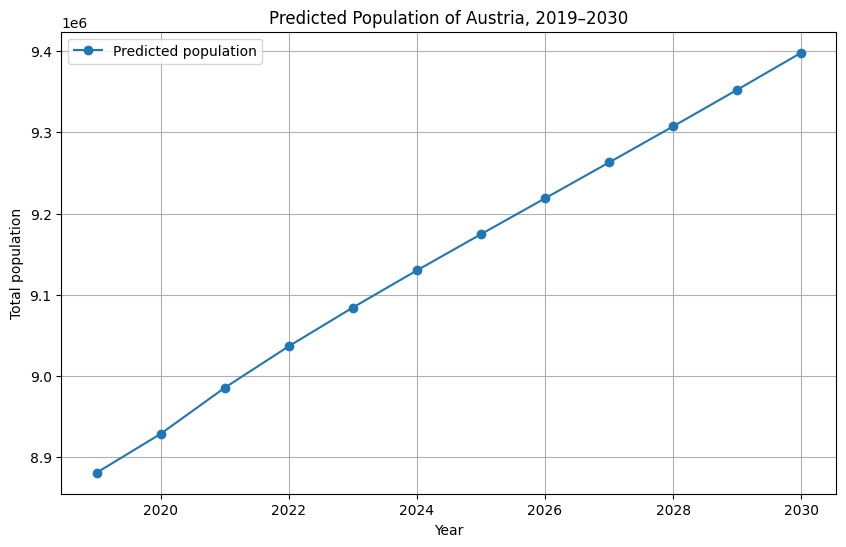

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    future_prediction_df["Year"],
    future_prediction_df["predicted_total_population"],
    marker="o",
    label="Predicted population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Predicted Population of Austria, 2019–2030")
plt.legend()
plt.grid(True)
plt.show()

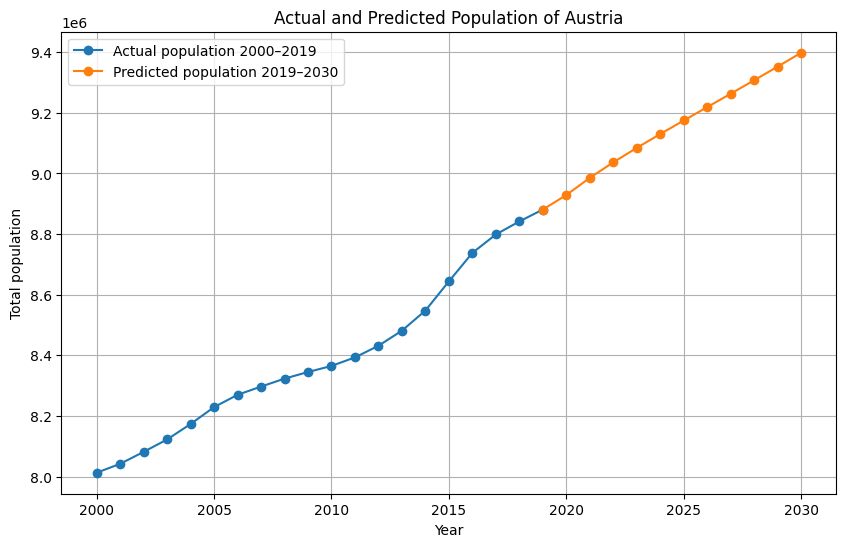

In [18]:
actual_total = (
    population_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "actual_total_population"})
)

plt.figure(figsize=(10, 6))

plt.plot(
    actual_total["Year"],
    actual_total["actual_total_population"],
    marker="o",
    label="Actual population 2000–2019"
)

plt.plot(
    future_prediction_df["Year"],
    future_prediction_df["predicted_total_population"],
    marker="o",
    label="Predicted population 2019–2030"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Actual and Predicted Population of Austria")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
un_projection_df = pd.read_csv("../dataset/cleaned_population_dataset_2020_2030.csv")

print(un_projection_df.head())
print(un_projection_df.shape)
print(un_projection_df["Year"].unique())
print(un_projection_df["Age"].unique())
print(un_projection_df["Sex"].unique())

   Year    Age   Sex  Population
0  2020      0  Male     86581.5
1  2020   1-14  Male    573639.5
2  2020  15-64  Male   2984993.5
3  2020  65-89  Male    719610.0
4  2020    90+  Male     24256.0
(110, 4)
[2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030]
['0' '1-14' '15-64' '65-89' '90+']
['Male' 'Female']


In [21]:
un_projection_df = pd.read_csv("../dataset/cleaned_population_dataset_2020_2030.csv")

In [22]:
un_projection_total = (
    un_projection_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "un_projected_total_population"})
)

un_projection_total

,Year,un_projected_total_population
0,2020,8921405.0
1,2021,8967056.5
2,2022,9064677.0
3,2023,9130429.0
4,2024,9120813.0
5,2025,9113574.0
6,2026,9107266.0
7,2027,9101493.0
8,2028,9096265.0
9,2029,9089763.5


In [23]:
task5_comparison_df = future_prediction_df[[
    "Year",
    "predicted_total_population"
]].merge(
    un_projection_total,
    on="Year",
    how="inner"
)

task5_comparison_df["absolute_error"] = abs(
    task5_comparison_df["predicted_total_population"] -
    task5_comparison_df["un_projected_total_population"]
)

task5_comparison_df["percentage_error"] = (
    task5_comparison_df["absolute_error"] /
    task5_comparison_df["un_projected_total_population"]
) * 100

task5_comparison_df

,Year,predicted_total_population,un_projected_total_population,absolute_error,percentage_error
0,2020,8.928763e+06,8921405.0,7358.308062,0.082479
1,2021,8.985521e+06,8967056.5,18464.798297,0.205918
2,2022,9.036604e+06,9064677.0,28072.743030,0.309694
3,2023,9.084307e+06,9130429.0,46121.505255,0.505141
4,2024,9.129986e+06,9120813.0,9172.944067,0.100572
5,2025,9.174573e+06,9113574.0,60998.722679,0.669317
6,2026,9.218727e+06,9107266.0,111461.259828,1.223872
7,2027,9.262897e+06,9101493.0,161403.529299,1.773374
8,2028,9.307373e+06,9096265.0,211107.582360,2.320816
9,2029,9.352390e+06,9089763.5,262626.336069,2.889254


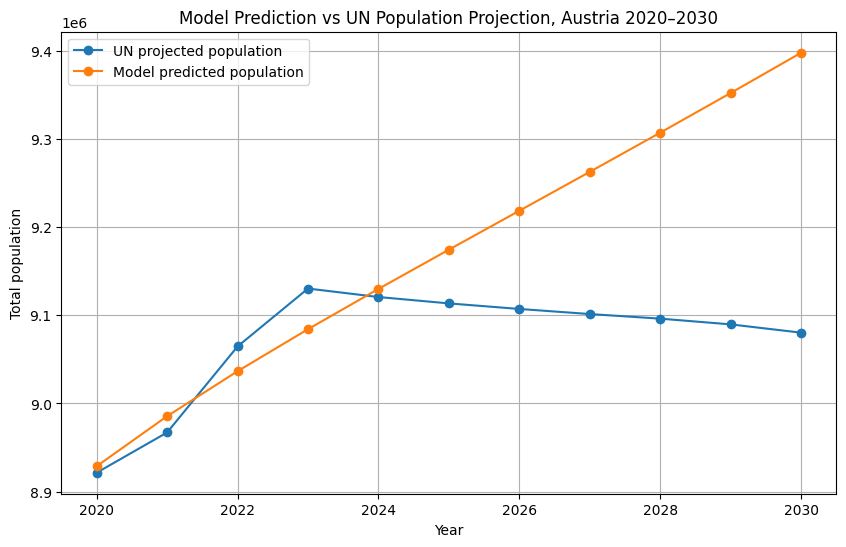

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    task5_comparison_df["Year"],
    task5_comparison_df["un_projected_total_population"],
    marker="o",
    label="UN projected population"
)

plt.plot(
    task5_comparison_df["Year"],
    task5_comparison_df["predicted_total_population"],
    marker="o",
    label="Model predicted population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Model Prediction vs UN Population Projection, Austria 2020–2030")
plt.legend()
plt.grid(True)
plt.show()